In [61]:
import collections
import os
import string
import sys

import pandas as pd
from nltk import word_tokenize
from nltk.corpus import stopwords
from pprint import pprint
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine

In [62]:
import nltk

nltk.download('punkt')
nltk.download("punkt_tab")

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


False

TP3 - Partie 1

In [63]:
data_path = "../../data/txt/"

In [64]:
DECADE = '1910'

In [65]:
files = [f for f in sorted(os.listdir(data_path)) if f"_{DECADE[:-1]}" in f]

texts = [open(data_path + f, "r", encoding="utf-8").read() for f in files]

In [66]:
def preprocessing(text, stem=True):
    """ Tokenize text and remove punctuation """
    text = text.translate(string.punctuation)
    tokens = word_tokenize(text)
    return tokens

In [67]:
vectorizer = TfidfVectorizer(
    tokenizer=preprocessing,
    stop_words=stopwords.words('french'),
    max_df=0.5,
    min_df=0.1,
    lowercase=True)

In [68]:
tfidf_vectors = vectorizer.fit_transform(texts)

/Users/iduoliveira/TACTEST/tac/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [69]:
N_CLUSTERS = 3

km_model = KMeans(n_clusters=N_CLUSTERS)

clusters = km_model.fit_predict(tfidf_vectors)

In [70]:
clustering = collections.defaultdict(list)

for idx, label in enumerate(clusters):
    clustering[label].append(files[idx])

In [71]:
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(tfidf_vectors.toarray())

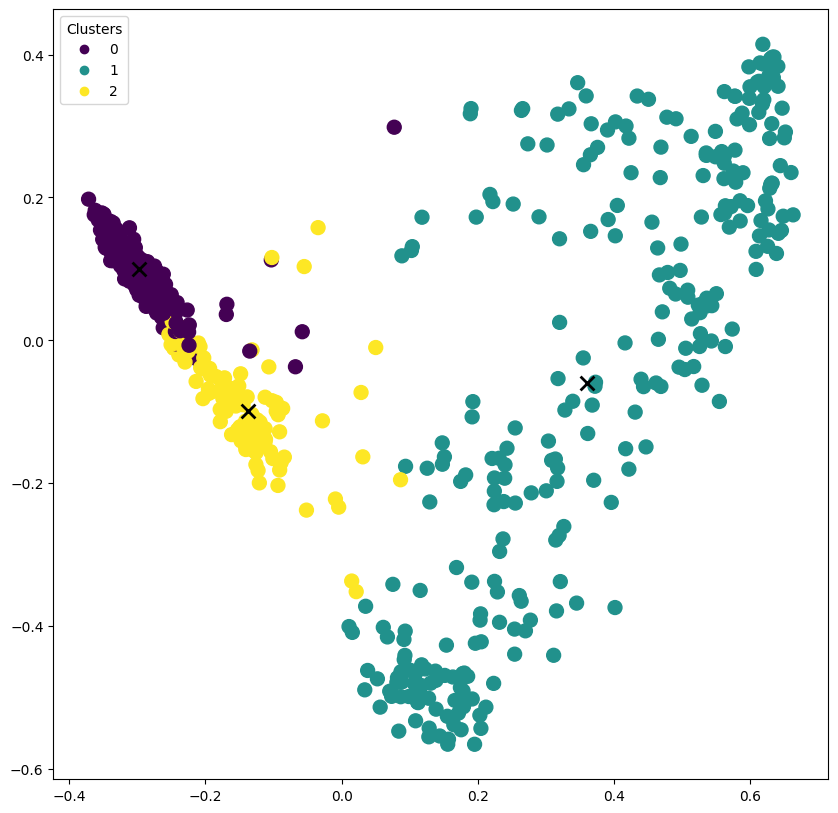

In [72]:
x_axis = reduced_vectors[:, 0]
y_axis = reduced_vectors[:, 1]

plt.figure(figsize=(10,10))
scatter = plt.scatter(x_axis, y_axis, s=100, c=clusters)

centroids = pca.transform(km_model.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],  marker = "x", s=100, linewidths = 2, color='black')

plt.legend(handles=scatter.legend_elements()[0], labels=set(clusters), title="Clusters")

TP3 - Partie 2 

In [73]:
import sys

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec

import nltk
from nltk.tokenize import wordpunct_tokenize
from unidecode import unidecode

In [74]:
class MySentences(object):
    """Tokenize and Lemmatize sentences"""
    def __init__(self, filename):
        self.filename = filename

    def __iter__(self):
        for line in open(self.filename, encoding='utf-8', errors="backslashreplace"):
            yield [unidecode(w.lower()) for w in wordpunct_tokenize(line)]

In [75]:
infile = f"../../data/sents1.txt"
sentences = MySentences(infile)

In [76]:
bigram_phrases = Phrases(sentences)

In [77]:
bigram_phraser = Phraser(phrases_model=bigram_phrases)

In [78]:
trigram_phrases = Phrases(bigram_phraser[sentences])

In [79]:
trigram_phraser = Phraser(phrases_model=trigram_phrases)

In [80]:
corpus = list(trigram_phraser[bigram_phraser[sentences]])

In [81]:
%%time
model1 = Word2Vec(
    corpus, 
    vector_size=32,
    window=5, 
    min_count=5, 
    workers=4,
    epochs=5 
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


CPU times: user 47.1 s, sys: 809 ms, total: 47.9 s
Wall time: 18.2 s


In [82]:
%%time
model2 = Word2Vec(
    corpus, 
    vector_size=32, 
    window=5, 
    min_count=2, 
    workers=4,
    epochs=5 
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


CPU times: user 53.5 s, sys: 985 ms, total: 54.5 s
Wall time: 20.6 s


In [83]:
%%time
model3 = Word2Vec(
    corpus, 
    vector_size=32, 
    window=9, 
    min_count=5, 
    workers=4, 
    epochs=5 
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


CPU times: user 48.8 s, sys: 918 ms, total: 49.7 s
Wall time: 18.3 s


In [84]:
%%time
model4 = Word2Vec(
    corpus, 
    vector_size=32, 
    window=9, 
    min_count=2, 
    workers=4, 
    epochs=5 
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


CPU times: user 60 s, sys: 2.43 s, total: 1min 2s
Wall time: 24.3 s


TP3 - Partie 3 1/2

In [85]:
model1.wv.similarity("garcon", "courses")

model1.wv.similarity("demande", "louer")

model1.wv.similarity("grand", "petit")

0.76938176

In [86]:
model2.wv.similarity("garcon", "courses")

model2.wv.similarity("demande", "louer")

model2.wv.similarity("grand", "petit")

0.8017274

In [87]:
model3.wv.similarity("garcon", "courses")

model3.wv.similarity("demande", "louer")

model3.wv.similarity("grand", "petit")

0.74374485

In [88]:
model4.wv.similarity("garcon", "courses")

model4.wv.similarity("demande", "louer")

model4.wv.similarity("grand", "petit")

0.7389767

TP3 - Partie 3 2/2

In [89]:
model1.wv.most_similar("royale", topn=10)

model1.wv.most_similar("officiers", topn=10)

model1.wv.most_similar("lettre", topn=10)

[('faire_part', 0.8158631920814514),
 ('reponse', 0.7802801728248596),
 ('lellre', 0.7737475037574768),
 ('auraient_pas_recu', 0.7338448166847229),
 ('part_sont_pries', 0.7200633883476257),
 ('pas_recu', 0.7194539904594421),
 (',_sont_pries', 0.7182475328445435),
 ('la_revision', 0.6991233825683594),
 ('considerer_le_present_avis', 0.693152904510498),
 ('mission', 0.6899762153625488)]

In [90]:
model2.wv.most_similar("royale", topn=10)

model2.wv.most_similar("officiers", topn=10)

model2.wv.most_similar("lettre", topn=10)

[('reponse', 0.801511824131012),
 ('faire_part', 0.7918530106544495),
 ('auraient_pas_recu', 0.7290079593658447),
 ('proposition', 0.7147420048713684),
 (',_sont_pries', 0.7123289108276367),
 ('pas_recu', 0.709922194480896),
 ('la_prevention', 0.7094236016273499),
 ('ecrouo', 0.705486536026001),
 ('iudignemem', 0.6987229585647583),
 ('la_presse', 0.6941190958023071)]

In [91]:
model3.wv.most_similar("royale", topn=10)

model3.wv.most_similar("officiers", topn=10)

model3.wv.most_similar("lettre", topn=10)

[('faire_part', 0.8330661654472351),
 ('reponse', 0.8281827569007874),
 (',_sont_pries', 0.794010579586029),
 ('les_amis', 0.7778468132019043),
 ('par_oubli', 0.7776069045066833),
 ('pas_recu', 0.7763785719871521),
 ('considerer_le_present_avis', 0.7740301489830017),
 ('raient_pas_recu', 0.7613157033920288),
 ('considerer_le_present', 0.7588751912117004),
 ('auraient_pas_recu', 0.7560586929321289)]

In [92]:
model4.wv.most_similar("royale", topn=10)

model4.wv.most_similar("officiers", topn=10)

model4.wv.most_similar("lettre", topn=10)

[('faire_part', 0.8394562005996704),
 ('considerer_lo_present_avis', 0.770423948764801),
 (',_sont_pries', 0.762384295463562),
 ('les_amis', 0.7574316263198853),
 ('reponse', 0.7498512864112854),
 ('deconsiderer_le_present_avis', 0.7489492893218994),
 ('raient_pas_recu', 0.7415480613708496),
 ('present_avis_comme', 0.7381157279014587),
 ('considerer_le_present', 0.7335048913955688),
 ('considerer_le_present_avis', 0.7302396893501282)]